This is a companion notebook for the book [Deep Learning with Python, Third Edition](https://www.manning.com/books/deep-learning-with-python-third-edition). For readability, it only contains runnable code blocks and section titles, and omits everything else in the book: text paragraphs, figures, and pseudocode.

**If you want to be able to follow what's going on, I recommend reading the notebook side by side with your copy of the book.**

The book's contents are available online at [deeplearningwithpython.io](https://deeplearningwithpython.io).

In [ ]:
!pip install keras keras-hub --upgrade -q

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "jax"

In [ ]:
# @title
import os
from IPython.core.magic import register_cell_magic

@register_cell_magic
def backend(line, cell):
    current, required = os.environ.get("KERAS_BACKEND", ""), line.split()[-1]
    if current == required:
        get_ipython().run_cell(cell)
    else:
        print(
            f"This cell requires the {required} backend. To run it, change KERAS_BACKEND to "
            f"\"{required}\" at the top of the notebook, restart the runtime, and rerun the notebook."
        )

## Fundamentals of machine learning

### Generalization: The goal of machine learning

#### Underfitting and overfitting

##### Noisy training data

##### Ambiguous features

##### Rare features and spurious correlations

In [1]:
from keras.datasets import mnist
import numpy as np

(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

train_images_with_noise_channels = np.concatenate(
    [train_images, np.random.random((len(train_images), 784))], axis=1
)

train_images_with_zeros_channels = np.concatenate(
    [train_images, np.zeros((len(train_images), 784))], axis=1
)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [3]:
np.random.random((len(train_images), 784)).shape

(60000, 784)

In [2]:
import keras
from keras import layers

def get_model():
    model = keras.Sequential(
        [
            layers.Dense(512, activation="relu"),
            layers.Dense(10, activation="softmax"),
        ]
    )
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"],
    )
    return model

model = get_model()
history_noise = model.fit(
    train_images_with_noise_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

model = get_model()
history_zeros = model.fit(
    train_images_with_zeros_channels,
    train_labels,
    epochs=10,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8623 - loss: 0.4601 - val_accuracy: 0.9095 - val_loss: 0.3058
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9318 - loss: 0.2347 - val_accuracy: 0.9357 - val_loss: 0.2159
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9508 - loss: 0.1646 - val_accuracy: 0.9523 - val_loss: 0.1695
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9651 - loss: 0.1177 - val_accuracy: 0.9547 - val_loss: 0.1473
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9752 - loss: 0.0850 - val_accuracy: 0.9607 - val_loss: 0.1346
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9818 - loss: 0.0619 - val_accuracy: 0.9632 - val_loss: 0.1303
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9883 - loss: 0.0421 - val_accuracy: 0.9621 - val_loss: 0.1334
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9929 - loss: 0.0290 - val_accuracy: 0.

In [6]:
history_noise.history

{'accuracy': [0.862291693687439,
  0.9318125247955322,
  0.9507708549499512,
  0.9651041626930237,
  0.9752291440963745,
  0.9817708134651184,
  0.9883124828338623,
  0.9929375052452087,
  0.9947291612625122,
  0.9982916712760925],
 'loss': [0.46007439494132996,
  0.23465745151042938,
  0.16456131637096405,
  0.11772952973842621,
  0.08502689003944397,
  0.061907459050416946,
  0.042149756103754044,
  0.0289520975202322,
  0.02170376107096672,
  0.0120628010481596],
 'val_accuracy': [0.909500002861023,
  0.9356666803359985,
  0.9522500038146973,
  0.9546666741371155,
  0.9607499837875366,
  0.9631666541099548,
  0.9620833396911621,
  0.9600833058357239,
  0.9645833373069763,
  0.9637500047683716],
 'val_loss': [0.30580100417137146,
  0.21585500240325928,
  0.16948813199996948,
  0.14730829000473022,
  0.13455067574977875,
  0.13031966984272003,
  0.13336403667926788,
  0.13173145055770874,
  0.12900619208812714,
  0.13820452988147736]}

In [7]:
history_zeros.history

{'accuracy': [0.9153333306312561,
  0.9634583592414856,
  0.976312518119812,
  0.984125018119812,
  0.9878125190734863,
  0.991895854473114,
  0.9940208196640015,
  0.9953333139419556,
  0.9972916841506958,
  0.9977291822433472],
 'loss': [0.30103638768196106,
  0.12645457684993744,
  0.08187931030988693,
  0.05633208900690079,
  0.04216338321566582,
  0.0310965608805418,
  0.023174408823251724,
  0.01842246577143669,
  0.012986850924789906,
  0.010175212286412716],
 'val_accuracy': [0.9548333287239075,
  0.9679166674613953,
  0.9729166626930237,
  0.971750020980835,
  0.9742500185966492,
  0.9771666526794434,
  0.9786666631698608,
  0.9773333072662354,
  0.9777500033378601,
  0.9784166812896729],
 'val_loss': [0.15992596745491028,
  0.10780397802591324,
  0.09222318232059479,
  0.08897677809000015,
  0.08419029414653778,
  0.07742913067340851,
  0.0760946124792099,
  0.07818786799907684,
  0.08167729526758194,
  0.07447750121355057]}

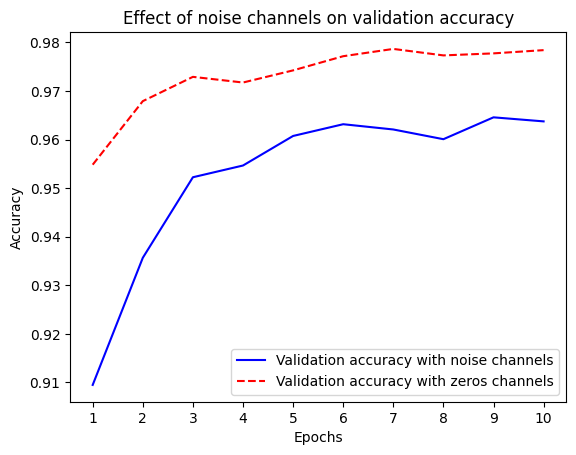

In [5]:
import matplotlib.pyplot as plt

val_acc_noise = history_noise.history["val_accuracy"]
val_acc_zeros = history_zeros.history["val_accuracy"]
# Using val_acc_original from kernel state as requested by the user
# Note: history_original was trained on IMDB data, while noise/zeros are from MNIST.
# Plotting them together might compare different contexts.
val_acc_original_from_kernel = val_acc_original

epochs = range(1, 11)
plt.plot(
    epochs,
    val_acc_noise,
    "b-",
    label="Validation accuracy with noise channels",
)
plt.plot(
    epochs,
    val_acc_zeros,
    "r--",
    label="Validation accuracy with zeros channels",
)
plt.plot(
    epochs,
    val_acc_original_from_kernel,
    "g:",
    label="Validation accuracy of original model (from kernel)",
)
plt.title("Effect of noise channels and original model on validation accuracy")
plt.xlabel("Epochs")
plt.xticks(epochs)
plt.ylabel("Accuracy")
plt.legend()
plt.show()

#### The nature of generalization in deep learning

In [9]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

random_train_labels = train_labels[:]
np.random.shuffle(random_train_labels)

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images,
    random_train_labels,
    epochs=100,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.1019 - loss: 2.3161 - val_accuracy: 0.1042 - val_loss: 2.3056
Epoch 2/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1148 - loss: 2.2996 - val_accuracy: 0.1006 - val_loss: 2.3135
Epoch 3/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1270 - loss: 2.2921 - val_accuracy: 0.1007 - val_loss: 2.3128
Epoch 4/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1350 - loss: 2.2805 - val_accuracy: 0.1026 - val_loss: 2.3240
Epoch 5/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1493 - loss: 2.2646 - val_accuracy: 0.1036 - val_loss: 2.3345
Epoch 6/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1632 - loss: 2.2469 - val_accuracy: 0.1026 - val_loss: 2.3396
Epoch 7/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1757 - loss: 2.2242 - val_accuracy: 0.1008 - val_loss: 2.3555
Epoch 8/100
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1932 - loss: 2.1986 - val_accu

##### The manifold hypothesis

##### Interpolation as a source of generalization

##### Why deep learning works

##### Training data is paramount

### Evaluating machine-learning models

#### Training, validation, and test sets

##### Simple hold-out validation

##### K-fold validation

##### Iterated K-fold validation with shuffling

#### Beating a common-sense baseline

#### Things to keep in mind about model evaluation

### Improving model fit

#### Tuning key gradient descent parameters

In [11]:
(train_images, train_labels), _ = mnist.load_data()
train_images = train_images.reshape((60000, 28 * 28))
train_images = train_images.astype("float32") / 255

model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1.0),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.3074 - loss: 690.5203 - val_accuracy: 0.2052 - val_loss: 3.6316
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1930 - loss: 2.8796 - val_accuracy: 0.2011 - val_loss: 2.2443
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.1803 - loss: 3.0791 - val_accuracy: 0.2135 - val_loss: 3.5837
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.1769 - loss: 2.5653 - val_accuracy: 0.1803 - val_loss: 2.2453
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.1972 - loss: 2.2906 - val_accuracy: 0.2037 - val_loss: 2.2025
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.2156 - loss: 2.3462 - val_accuracy: 0.2120 - val_loss: 2.1859
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2103 - loss: 2.4420 - val_accuracy: 0.2178 - val_loss: 2.1147
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.2105 - loss: 2.3251 - val_accuracy: 

In [12]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer=keras.optimizers.RMSprop(learning_rate=1e-2),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.fit(
    train_images, train_labels, epochs=10, batch_size=128, validation_split=0.2
)

Epoch 1/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.9083 - loss: 0.3837 - val_accuracy: 0.9564 - val_loss: 0.1525
Epoch 2/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9650 - loss: 0.1267 - val_accuracy: 0.9600 - val_loss: 0.1542
Epoch 3/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9744 - loss: 0.0950 - val_accuracy: 0.9629 - val_loss: 0.1655
Epoch 4/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9779 - loss: 0.0831 - val_accuracy: 0.9743 - val_loss: 0.1451
Epoch 5/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9812 - loss: 0.0722 - val_accuracy: 0.9697 - val_loss: 0.1763
Epoch 6/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9856 - loss: 0.0593 - val_accuracy: 0.9705 - val_loss: 0.1921
Epoch 7/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9871 - loss: 0.0562 - val_accuracy: 0.9715 - val_loss: 0.1875
Epoch 8/10
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9885 - loss: 0.0454 - val_accuracy: 0.

#### Using better architecture priors

#### Increasing model capacity

In [13]:
model = keras.Sequential([layers.Dense(10, activation="softmax")])
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_small_model = model.fit(
    train_images, train_labels, epochs=20, batch_size=128, validation_split=0.2
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8352 - loss: 0.6673 - val_accuracy: 0.9046 - val_loss: 0.3608
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9028 - loss: 0.3538 - val_accuracy: 0.9147 - val_loss: 0.3105
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9114 - loss: 0.3187 - val_accuracy: 0.9199 - val_loss: 0.2924
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9159 - loss: 0.3026 - val_accuracy: 0.9233 - val_loss: 0.2839
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9188 - loss: 0.2930 - val_accuracy: 0.9241 - val_loss: 0.2789
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9201 - loss: 0.2860 - val_accuracy: 0.9244 - val_loss: 0.2753
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9217 - loss: 0.2811 - val_accuracy: 0.9262 - val_loss: 0.2718
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9227 - loss: 0.2772 - val_accuracy: 0.

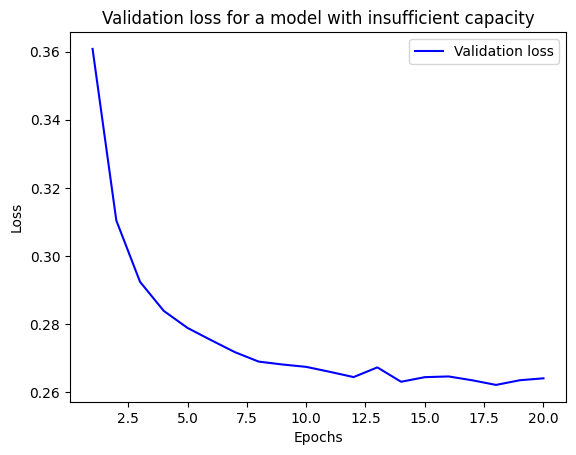

In [14]:
import matplotlib.pyplot as plt

val_loss = history_small_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with insufficient capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [15]:
model = keras.Sequential(
    [
        layers.Dense(128, activation="relu"),
        layers.Dense(128, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_large_model = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=128,
    validation_split=0.2,
)

Epoch 1/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - accuracy: 0.8995 - loss: 0.3511 - val_accuracy: 0.9487 - val_loss: 0.1750
Epoch 2/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9564 - loss: 0.1469 - val_accuracy: 0.9631 - val_loss: 0.1222
Epoch 3/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9703 - loss: 0.1003 - val_accuracy: 0.9679 - val_loss: 0.1055
Epoch 4/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9773 - loss: 0.0747 - val_accuracy: 0.9709 - val_loss: 0.0945
Epoch 5/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9824 - loss: 0.0571 - val_accuracy: 0.9728 - val_loss: 0.0955
Epoch 6/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9858 - loss: 0.0449 - val_accuracy: 0.9747 - val_loss: 0.0940
Epoch 7/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9893 - loss: 0.0361 - val_accuracy: 0.9763 - val_loss: 0.0922
Epoch 8/20
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9912 - loss: 0.0296 - val_accuracy: 0.

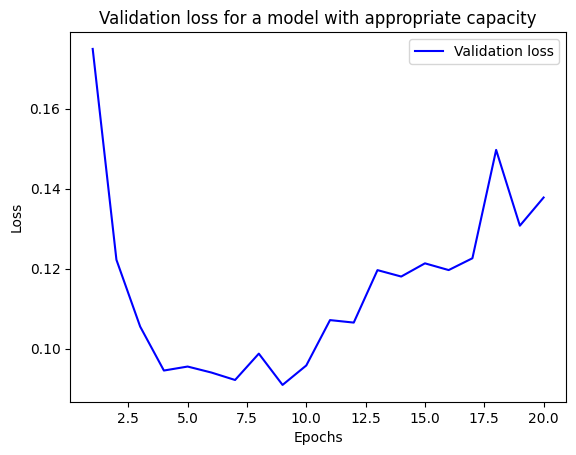

In [16]:
val_loss = history_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with appropriate capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [17]:
model = keras.Sequential(
    [
        layers.Dense(2048, activation="relu"),
        layers.Dense(2048, activation="relu"),
        layers.Dense(2048, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
history_very_large_model = model.fit(
    train_images,
    train_labels,
    epochs=20,
    batch_size=32,
    validation_split=0.2,
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9256 - loss: 0.2580 - val_accuracy: 0.9599 - val_loss: 0.1577
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9695 - loss: 0.1159 - val_accuracy: 0.9646 - val_loss: 0.1347
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9791 - loss: 0.0830 - val_accuracy: 0.9750 - val_loss: 0.1253
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9827 - loss: 0.0680 - val_accuracy: 0.9741 - val_loss: 0.1283
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9873 - loss: 0.0540 - val_accuracy: 0.9704 - val_loss: 0.1487
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9898 - loss: 0.0424 - val_accuracy: 0.9755 - val_loss: 0.1624
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.9914 - loss: 0.0338 - val_accuracy: 0.9776 - val_loss: 0.1603
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.9925 - loss: 0.0336 -

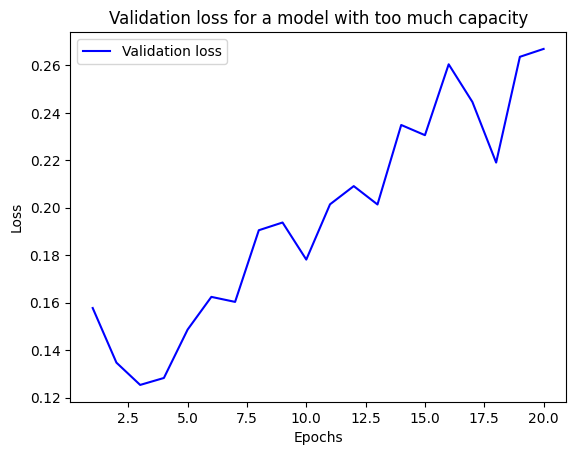

In [18]:
val_loss = history_very_large_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(epochs, val_loss, "b-", label="Validation loss")
plt.title("Validation loss for a model with too much capacity")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

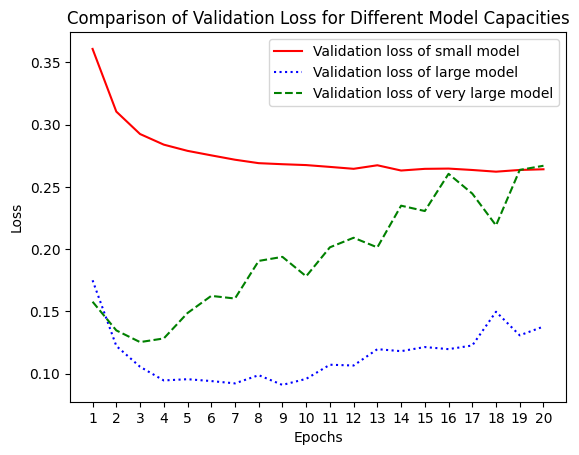

In [20]:
import matplotlib.pyplot as plt

small_model_val_loss = history_small_model.history["val_loss"]
large_model_val_loss = history_large_model.history["val_loss"]
very_large_model_val_loss = history_very_large_model.history["val_loss"]

epochs = range(1, 21)

plt.plot(
    epochs,
    small_model_val_loss,
    "r-",
    label="Validation loss of small model",
)
plt.plot(
    epochs,
    large_model_val_loss,
    "b:",
    label="Validation loss of large model",
)
plt.plot(
    epochs,
    very_large_model_val_loss,
    "g--",
    label="Validation loss of very large model",
)

plt.title("Comparison of Validation Loss for Different Model Capacities")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

### Improving generalization

#### Dataset curation

#### Feature engineering

#### Using early stopping

#### Regularizing your model

##### Reducing the network's size

In [21]:
from keras.datasets import imdb

(train_data, train_labels), _ = imdb.load_data(num_words=10000)

def vectorize_sequences(sequences, dimension=10000):
    results = np.zeros((len(sequences), dimension))
    for i, sequence in enumerate(sequences):
        results[i, sequence] = 1.0
    return results

train_data = vectorize_sequences(train_data)

model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dense(16, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_original = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

17464789/17464789 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 4s 96ms/step - accuracy: 0.7674 - loss: 0.5521 - val_accuracy: 0.8333 - val_loss: 0.4543
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8899 - loss: 0.3566 - val_accuracy: 0.8758 - val_loss: 0.3395
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9158 - loss: 0.2645 - val_accuracy: 0.8686 - val_loss: 0.3238
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9307 - loss: 0.2152 - val_accuracy: 0.8924 - val_loss: 0.2771
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9433 - loss: 0.1783 - val_accuracy: 0.8789 - val_loss: 0.2992
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9543 - loss: 0.1511 - val_accuracy: 0.8837 - val_loss: 0.2934
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - accuracy: 0.9587 - loss: 0.1308 - val_accuracy: 0.8834 - val_loss: 0.3002
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 36ms/step - accurac

In [22]:
model = keras.Sequential(
    [
        layers.Dense(4, activation="relu"),
        layers.Dense(4, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_smaller_model = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 103ms/step - accuracy: 0.7417 - loss: 0.6161 - val_accuracy: 0.8442 - val_loss: 0.5371
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8725 - loss: 0.4761 - val_accuracy: 0.8696 - val_loss: 0.4407
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8953 - loss: 0.3811 - val_accuracy: 0.8765 - val_loss: 0.3721
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9089 - loss: 0.3117 - val_accuracy: 0.8825 - val_loss: 0.3299
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9217 - loss: 0.2635 - val_accuracy: 0.8866 - val_loss: 0.3035
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9295 - loss: 0.2282 - val_accuracy: 0.8891 - val_loss: 0.2879
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9371 - loss: 0.2014 - val_accuracy: 0.8916 - val_loss: 0.2796
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9455 - loss: 0.1792 - val_accuracy: 0.8862 - 

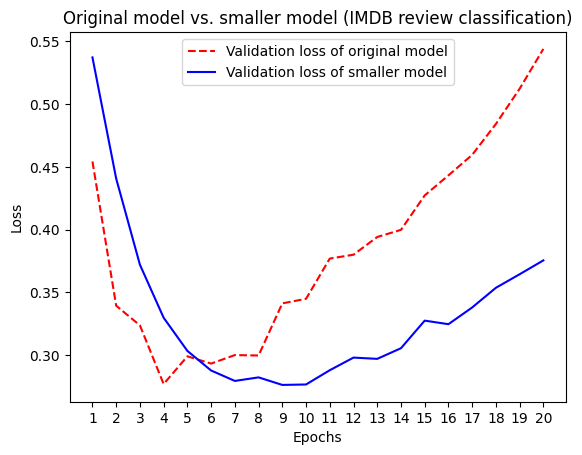

In [23]:
original_val_loss = history_original.history["val_loss"]
smaller_model_val_loss = history_smaller_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    smaller_model_val_loss,
    "b-",
    label="Validation loss of smaller model",
)
plt.title("Original model vs. smaller model (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

In [24]:
model = keras.Sequential(
    [
        layers.Dense(512, activation="relu"),
        layers.Dense(512, activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_larger_model = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 124ms/step - accuracy: 0.7418 - loss: 0.5672 - val_accuracy: 0.7379 - val_loss: 0.5327
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8683 - loss: 0.3228 - val_accuracy: 0.8662 - val_loss: 0.3214
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - accuracy: 0.8981 - loss: 0.2457 - val_accuracy: 0.8794 - val_loss: 0.2988
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9300 - loss: 0.1861 - val_accuracy: 0.8853 - val_loss: 0.2880
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9507 - loss: 0.1352 - val_accuracy: 0.8627 - val_loss: 0.3555
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9640 - loss: 0.1028 - val_accuracy: 0.8794 - val_loss: 0.3462
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9756 - loss: 0.0770 - val_accuracy: 0.8877 - val_loss: 0.3666
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step - accuracy: 0.9765 - loss: 0.0874 - val_accuracy: 0.8854 - 

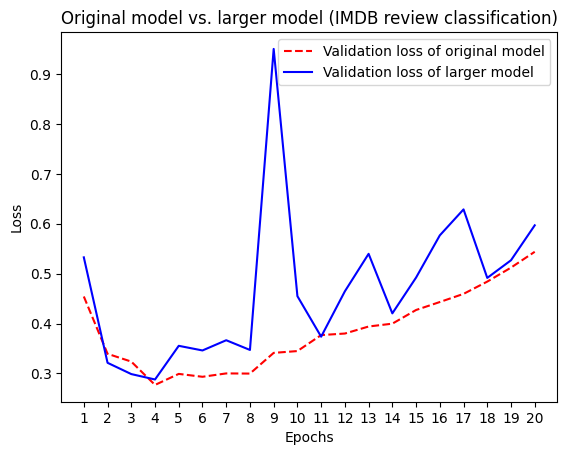

In [25]:
original_val_loss = history_original.history["val_loss"]
larger_model_val_loss = history_larger_model.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    larger_model_val_loss,
    "b-",
    label="Validation loss of larger model",
)
plt.title("Original model vs. larger model (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

##### Adding weight regularization

In [26]:
from keras.regularizers import l2

model = keras.Sequential(
    [
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(16, kernel_regularizer=l2(0.002), activation="relu"),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_l2_reg = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 101ms/step - accuracy: 0.7705 - loss: 0.5997 - val_accuracy: 0.8570 - val_loss: 0.4675
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.8921 - loss: 0.3984 - val_accuracy: 0.8843 - val_loss: 0.3885
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.9163 - loss: 0.3249 - val_accuracy: 0.8904 - val_loss: 0.3592
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9254 - loss: 0.2893 - val_accuracy: 0.8835 - val_loss: 0.3637
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 24ms/step - accuracy: 0.9354 - loss: 0.2642 - val_accuracy: 0.8893 - val_loss: 0.3524
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9381 - loss: 0.2542 - val_accuracy: 0.8869 - val_loss: 0.3550
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 41ms/step - accuracy: 0.9429 - loss: 0.2422 - val_accuracy: 0.8840 - val_loss: 0.3673
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - accuracy: 0.9499 - loss: 0.2304 - val_accuracy: 0.8827 - 

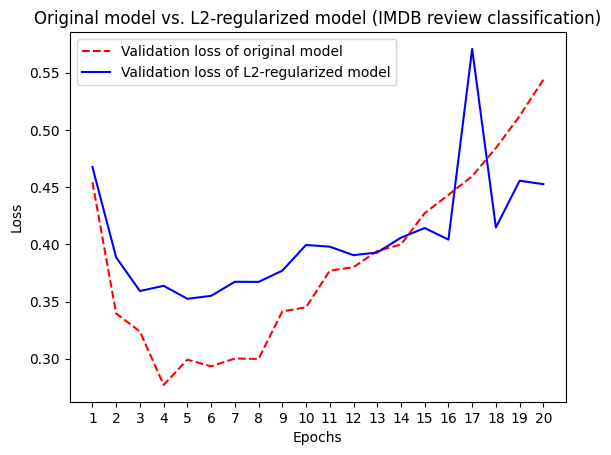

In [27]:
original_val_loss = history_original.history["val_loss"]
l2_val_loss = history_l2_reg.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    l2_val_loss,
    "b-",
    label="Validation loss of L2-regularized model",
)
plt.title(
    "Original model vs. L2-regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

In [28]:
from keras import regularizers

regularizers.l1(0.001)
regularizers.l1_l2(l1=0.001, l2=0.001)

##### Adding dropout

In [29]:
model = keras.Sequential(
    [
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(16, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_dropout = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 114ms/step - accuracy: 0.6037 - loss: 0.6640 - val_accuracy: 0.7142 - val_loss: 0.6208
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.7530 - loss: 0.5851 - val_accuracy: 0.7985 - val_loss: 0.5395
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8299 - loss: 0.5131 - val_accuracy: 0.8541 - val_loss: 0.4810
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8710 - loss: 0.4667 - val_accuracy: 0.8599 - val_loss: 0.4467
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.8924 - loss: 0.4143 - val_accuracy: 0.8632 - val_loss: 0.4177
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9059 - loss: 0.3715 - val_accuracy: 0.8815 - val_loss: 0.3793
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.9177 - loss: 0.3323 - val_accuracy: 0.8812 - val_loss: 0.3609
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 44ms/step - accuracy: 0.9283 - loss: 0.2982 - val_accuracy: 0.8799 - 

In [32]:
model = keras.Sequential(
    [
        layers.Dense(11, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(11, activation="relu"),
        layers.Dropout(0.5),
        layers.Dense(1, activation="sigmoid"),
    ]
)
model.compile(
    optimizer="rmsprop",
    loss="binary_crossentropy",
    metrics=["accuracy"],
)
history_dropout_mine = model.fit(
    train_data,
    train_labels,
    epochs=20,
    batch_size=512,
    validation_split=0.4,
)

Epoch 1/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 6s 126ms/step - accuracy: 0.6293 - loss: 0.6416 - val_accuracy: 0.8404 - val_loss: 0.5390
Epoch 2/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.7415 - loss: 0.5398 - val_accuracy: 0.8672 - val_loss: 0.4393
Epoch 3/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 2s 42ms/step - accuracy: 0.7910 - loss: 0.4735 - val_accuracy: 0.8790 - val_loss: 0.3758
Epoch 4/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - accuracy: 0.8277 - loss: 0.4179 - val_accuracy: 0.8804 - val_loss: 0.3394
Epoch 5/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.8508 - loss: 0.3763 - val_accuracy: 0.8887 - val_loss: 0.3054
Epoch 6/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8771 - loss: 0.3376 - val_accuracy: 0.8895 - val_loss: 0.2846
Epoch 7/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - accuracy: 0.8876 - loss: 0.3113 - val_accuracy: 0.8899 - val_loss: 0.2799
Epoch 8/20
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9015 - loss: 0.2832 - val_accuracy: 0.8884 - 

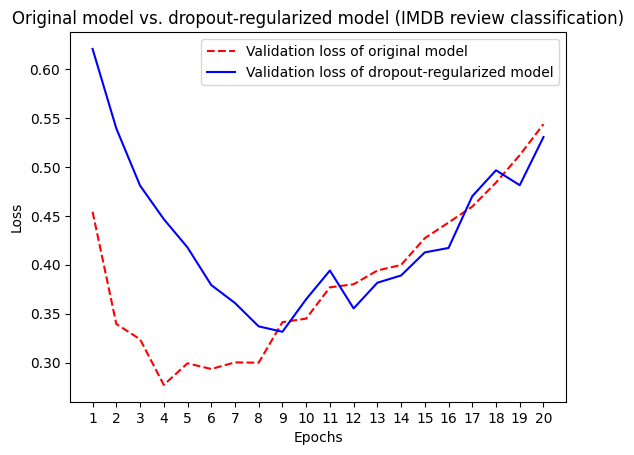

In [30]:
original_val_loss = history_original.history["val_loss"]
dropout_val_loss = history_dropout.history["val_loss"]
epochs = range(1, 21)
plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    dropout_val_loss,
    "b-",
    label="Validation loss of dropout-regularized model",
)
plt.title(
    "Original model vs. dropout-regularized model (IMDB review classification)"
)
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()

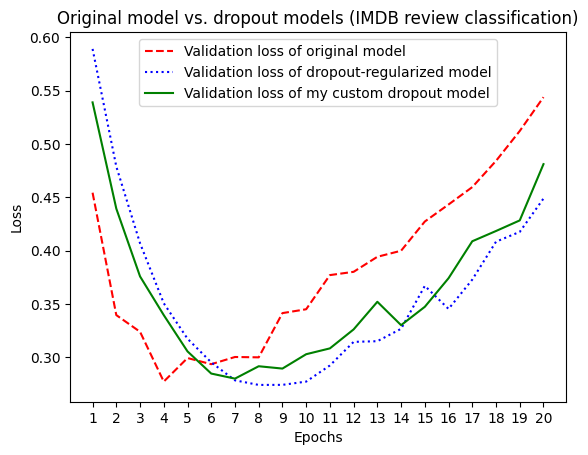

In [33]:
import matplotlib.pyplot as plt

original_val_loss = history_original.history["val_loss"]
dropout_val_loss = history_dropout.history["val_loss"]
dropout_mine_val_loss = history_dropout_mine.history["val_loss"]

epochs = range(1, 21)

plt.plot(
    epochs,
    original_val_loss,
    "r--",
    label="Validation loss of original model",
)
plt.plot(
    epochs,
    dropout_val_loss,
    "b:",
    label="Validation loss of dropout-regularized model",
)
plt.plot(
    epochs,
    dropout_mine_val_loss,
    "g-",
    label="Validation loss of my custom dropout model",
)

plt.title("Original model vs. dropout models (IMDB review classification)")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.xticks(epochs)
plt.legend()
plt.show()